# Graphical Lasso

Infer sparse conditional dependencies by estimating a Gaussian precision matrix. Start with a known synthetic graph, follow a regularization path, and select a penalty using held-out likelihood rather than access to the true graph.


## Run this tour

Run the cells in order with a Python 3 kernel. The first cell locates the companion data and toolbox and installs missing dependencies when needed. All worked examples include their implementation directly in this notebook. Random seeds make comparisons reproducible; you can change them to explore other samples.


In [1]:
# Locate the companion toolbox locally, or fetch it for a standalone/Colab copy.
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

working = Path.cwd()
candidates = [working, working / "python", working.parent / "python"]
python_dir = next((p for p in candidates if (p / "nt_toolbox").is_dir()), None)
if python_dir is None:
    checkout = working / "numerical-tours-support"
    if not checkout.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "master",
                "https://github.com/gpeyre/numerical-tours.git",
                str(checkout),
            ],
            check=True,
        )
    python_dir = checkout / "python"
os.chdir(python_dir)
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))
requirements = python_dir / "requirements.txt"
if any(
    importlib.util.find_spec(name) is None
    for name in [
        "numpy",
        "scipy",
        "matplotlib",
        "skimage",
        "sklearn",
        "pywt",
        "ipywidgets",
        "cvxpy",
        "skfmm",
        "autograd",
        "progressbar",
        "celer",
    ]
):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(requirements)], check=True
    )

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "figure.dpi": 100,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "image.cmap": "gray",
    }
)
%matplotlib inline


$\newcommand{\dotp}[2]{\langle #1, #2 \rangle}$
$\newcommand{\enscond}[2]{\lbrace #1, #2 \rbrace}$
$\newcommand{\pd}[2]{ \frac{ \partial #1}{\partial #2} }$
$\newcommand{\umin}[1]{\underset{#1}{\min}\;}$
$\newcommand{\umax}[1]{\underset{#1}{\max}\;}$
$\newcommand{\uargmin}[1]{\underset{#1}{argmin}\;}$
$\newcommand{\norm}[1]{\|#1\|}$
$\newcommand{\abs}[1]{\left|#1\right|}$
$\newcommand{\choice}[1]{ \left\{  \begin{array}{l} #1 \end{array} \right. }$
$\newcommand{\pa}[1]{\left(#1\right)}$
$\newcommand{\diag}[1]{{diag}\left( #1 \right)}$
$\newcommand{\qandq}{\quad\text{and}\quad}$
$\newcommand{\qwhereq}{\quad\text{where}\quad}$
$\newcommand{\qifq}{ \quad \text{if} \quad }$
$\newcommand{\qarrq}{ \quad \Longrightarrow \quad }$
$\newcommand{\ZZ}{\mathbb{Z}}$
$\newcommand{\CC}{\mathbb{C}}$
$\newcommand{\RR}{\mathbb{R}}$
$\newcommand{\EE}{\mathbb{E}}$
$\newcommand{\Zz}{\mathcal{Z}}$
$\newcommand{\Ww}{\mathcal{W}}$
$\newcommand{\Vv}{\mathcal{V}}$
$\newcommand{\Nn}{\mathcal{N}}$
$\newcommand{\NN}{\mathcal{N}}$
$\newcommand{\Hh}{\mathcal{H}}$
$\newcommand{\Bb}{\mathcal{B}}$
$\newcommand{\Ee}{\mathcal{E}}$
$\newcommand{\Cc}{\mathcal{C}}$
$\newcommand{\Gg}{\mathcal{G}}$
$\newcommand{\Ss}{\mathcal{S}}$
$\newcommand{\Pp}{\mathcal{P}}$
$\newcommand{\Ff}{\mathcal{F}}$
$\newcommand{\Xx}{\mathcal{X}}$
$\newcommand{\Mm}{\mathcal{M}}$
$\newcommand{\Ii}{\mathcal{I}}$
$\newcommand{\Dd}{\mathcal{D}}$
$\newcommand{\Ll}{\mathcal{L}}$
$\newcommand{\Tt}{\mathcal{T}}$
$\newcommand{\si}{\sigma}$
$\newcommand{\al}{\alpha}$
$\newcommand{\la}{\lambda}$
$\newcommand{\ga}{\gamma}$
$\newcommand{\Ga}{\Gamma}$
$\newcommand{\La}{\Lambda}$
$\newcommand{\Si}{\Sigma}$
$\newcommand{\be}{\beta}$
$\newcommand{\de}{\delta}$
$\newcommand{\De}{\Delta}$
$\newcommand{\phi}{\varphi}$
$\newcommand{\th}{\theta}$
$\newcommand{\om}{\omega}$
$\newcommand{\Om}{\Omega}$
$\newcommand{\eqdef}{\equiv}$


Graphical lasso estimates conditional relationships through a sparse precision matrix. Neighborhood selection, studied by Meinshausen and Bühlmann, offers a related regression-based approach. Here we solve the penalized Gaussian likelihood introduced by Banerjee, El Ghaoui, and d’Aspremont and popularized by Friedman, Hastie, and Tibshirani; the reading list gives these original sources.

## Sparse conditional dependence

For Gaussian data, a zero off-diagonal precision coefficient means conditional independence. We estimate a positive definite matrix $\Theta$ by minimizing
$$-\log\det\Theta+\operatorname{tr}(S\Theta)+\alpha\sum_{i\ne j}|\Theta_{ij}|.$$
Here $S$ is the empirical covariance. We generate a chain graph so that the true sparsity pattern is known, then compare the empirical inverse covariance with regularized estimates. The diagonal is not penalized.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.covariance import graphical_lasso

rng = np.random.default_rng(7)
p = 20
precision_true = np.diag(np.full(p, 1.4))
precision_true += np.diag(np.full(p - 1, -0.4), 1)
precision_true += np.diag(np.full(p - 1, -0.4), -1)
covariance_true = np.linalg.inv(precision_true)
X = rng.multivariate_normal(np.zeros(p), covariance_true, size=120)
X -= X.mean(axis=0)
S = X.T @ X / len(X)
empirical_precision = np.linalg.inv(S)

## Fit the regularization path

Increasing the penalty removes weak conditional relationships. We monitor the number of edges and the distance to the known precision matrix. The best penalty for prediction need not recover every edge, so these two diagnostics answer different questions.


[Text(0.5, 0, 'Penalty'), Text(0, 0.5, 'Estimated edges')]

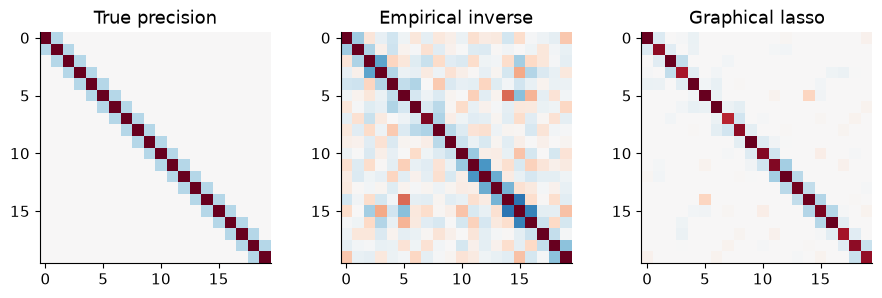

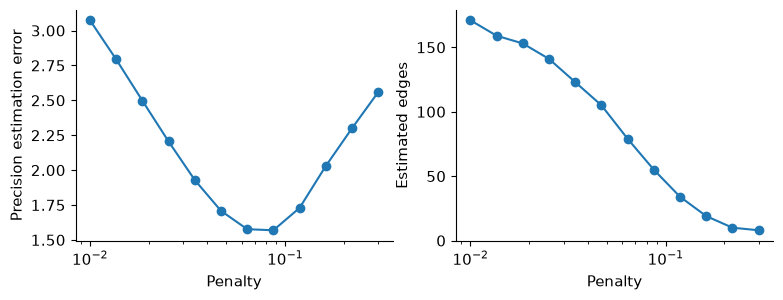

In [3]:
alphas = np.geomspace(0.01, 0.3, 12)
estimates = []
errors = []
edges = []
for alpha in alphas:
    covariance, precision = graphical_lasso(
        S, alpha=alpha, max_iter=1000, tol=1e-6, enet_tol=1e-9
    )
    estimates.append(precision)
    errors.append(np.linalg.norm(precision - precision_true, "fro"))
    edges.append((np.count_nonzero(np.abs(precision) > 1e-6) - p) // 2)
    assert np.linalg.eigvalsh(precision).min() > 0
    assert np.linalg.norm(covariance @ precision - np.eye(p)) < 1e-3
best = int(np.argmin(errors))
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, matrix, title in zip(
    axes,
    [precision_true, empirical_precision, estimates[best]],
    ["True precision", "Empirical inverse", "Graphical lasso"],
):
    ax.imshow(matrix, cmap="RdBu_r", vmin=-1.4, vmax=1.4)
    ax.set_title(title)
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].semilogx(alphas, errors, "o-")
axes[0].set(xlabel="Penalty", ylabel="Precision estimation error")
axes[1].semilogx(alphas, edges, "o-")
axes[1].set(xlabel="Penalty", ylabel="Estimated edges")

## Select the penalty without the ground truth

The previous comparison is possible because we simulated the data. In applications, use held-out likelihood or cross-validation. We split the samples before estimating means and covariances, select the penalty on validation likelihood, and reserve an independent test sample for the final assessment.


In [4]:
train, validation = X[:80], X[80:]
mean_train = train.mean(axis=0)
S_train = (train - mean_train).T @ (train - mean_train) / len(train)
S_val = (validation - mean_train).T @ (validation - mean_train) / len(validation)
validation_loss = []
for alpha in alphas:
    _, precision = graphical_lasso(
        S_train, alpha=alpha, max_iter=1000, tol=1e-6, enet_tol=1e-9
    )
    validation_loss.append(
        np.trace(S_val @ precision) - np.linalg.slogdet(precision)[1]
    )
alpha_selected = alphas[np.argmin(validation_loss)]
_, precision = graphical_lasso(
    S, alpha=alpha_selected, max_iter=1000, tol=1e-6, enet_tol=1e-9
)
X_test = rng.multivariate_normal(np.zeros(p), covariance_true, size=500)
S_test = X_test.T @ X_test / len(X_test)
test_loss = np.trace(S_test @ precision) - np.linalg.slogdet(precision)[1]
print(
    f"Selected penalty: {alpha_selected:.3f}; test negative log-likelihood (up to constants): {test_loss:.3f}"
)
assert np.isfinite(test_loss)

Selected penalty: 0.064; test negative log-likelihood (up to constants): 15.848


## References and further reading

- Jerome Friedman, Trevor Hastie, and Robert Tibshirani. [Sparse Inverse Covariance Estimation with the Graphical Lasso](https://doi.org/10.1093/biostatistics/kxm045). 2008, Biostatistics 9(3), 432–441. Coordinate descent for sparse Gaussian precision matrices.

- Onureena Banerjee, Laurent El Ghaoui, and Alexandre d’Aspremont. [Model Selection Through Sparse Maximum Likelihood Estimation for Multivariate Gaussian or Binary Data](https://www.jmlr.org/papers/v9/banerjee08a.html). 2008, JMLR 9, 485–516. The convex sparse covariance estimation problem.

- Nicolai Meinshausen and Peter Bühlmann. [High-Dimensional Graphs and Variable Selection with the Lasso](https://doi.org/10.1214/009053606000000281). 2006, Annals of Statistics 34(3), 1436–1462. Neighborhood selection and conditional-independence graphs.

- Robert Tibshirani. [Regression Shrinkage and Selection via the Lasso](https://doi.org/10.1111/j.2517-6161.1996.tb02080.x). 1996, Journal of the Royal Statistical Society B 58(1), 267–288. Sparse regression through an absolute-value penalty.

- Stephen Boyd and Lieven Vandenberghe. [Convex Optimization](https://web.stanford.edu/~boyd/cvxbook/). 2004, Cambridge University Press. Convexity, duality, optimality conditions, and interior-point methods.

- Trevor Hastie, Robert Tibshirani, and Jerome Friedman. [The Elements of Statistical Learning](https://hastie.su.domains/ElemStatLearn/). 2009, 2nd ed., Springer. Regression, classification, regularization, and model assessment.
